## PCA implementation

Image shape: (400, 64, 64)
Pixel range: 0.0 1.0


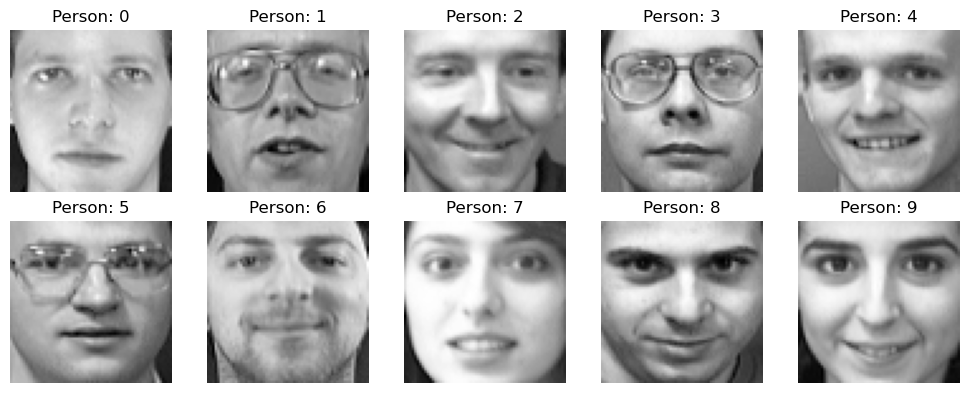

In [2]:
import numpy as np
import matplotlib.pyplot as plt

# Load dataset
images = np.load("../data/olivetti_faces/olivetti_faces.npy")
targets = np.load("../data/olivetti_faces/olivetti_faces_target.npy")

print("Image shape:", images.shape)
print("Pixel range:", images.min(), images.max())

# Show some example images
fig, axes = plt.subplots(2, 5, figsize=(10, 4))

indices = [0, 10, 20, 30, 40, 50, 60, 70, 80, 90]

for idx, ax in zip(indices, axes.flat):
    ax.imshow(images[idx], cmap="gray")
    ax.set_title(f"Person: {targets[idx]}")
    ax.axis("off")

plt.tight_layout()
plt.show()

In [8]:
def pca_images(images, k):
    # 1. Convert images to a 2D matrix
    # Each row = one image, each column = one pixel
    X = images.reshape(images.shape[0], -1)

    # Center the data
    mean_image = np.mean(X, axis=0)
    X_centered = X - mean_image

    # 2. Compute covariance matrix
    covariance_matrix = (
        X_centered.T @ X_centered
    ) / (X_centered.shape[0] - 1)

    # 3. Calculate eigenvalues and eigenvectors
    eigenvalues, eigenvectors = np.linalg.eigh(covariance_matrix)

    # 4. Sort eigenvalues and eigenvectors in descending order
    sorted_indices = np.argsort(eigenvalues)[::-1]
    eigenvalues = eigenvalues[sorted_indices]
    eigenvectors = eigenvectors[:, sorted_indices]

    # 5. Select the top k eigenvectors
    principal_components = eigenvectors[:, :k]

    # 6. Project images onto the lower-dimensional subspace
    X_projected = X_centered @ principal_components

    return (
        X,
        X_centered,
        mean_image,
        eigenvalues,
        eigenvectors,
        principal_components,
        X_projected
    )

In [34]:
# Run PCA using the first 50 principal components
k = 50

(
    X,
    X_centered,
    mean_image,
    eigenvalues,
    eigenvectors,
    principal_components,
    X_projected
) = pca_images(images, k)

# Check the dimensions before and after PCA
print("Image matrix:", X.shape)
print("Principal components:", principal_components.shape)
print("Projected data:", X_projected.shape)

Image matrix: (400, 4096)
Principal components: (4096, 50)
Projected data: (400, 50)


## Reconstruction of images

In [11]:
# Reconstruct the images
X_reconstructed = X_projected @ principal_components.T + mean_image

# Reshape the flattened images back to 64 x 64
reconstructed_images = X_reconstructed.reshape(images.shape)

print("Reconstructed images:", reconstructed_images.shape)

Reconstructed images: (400, 64, 64)


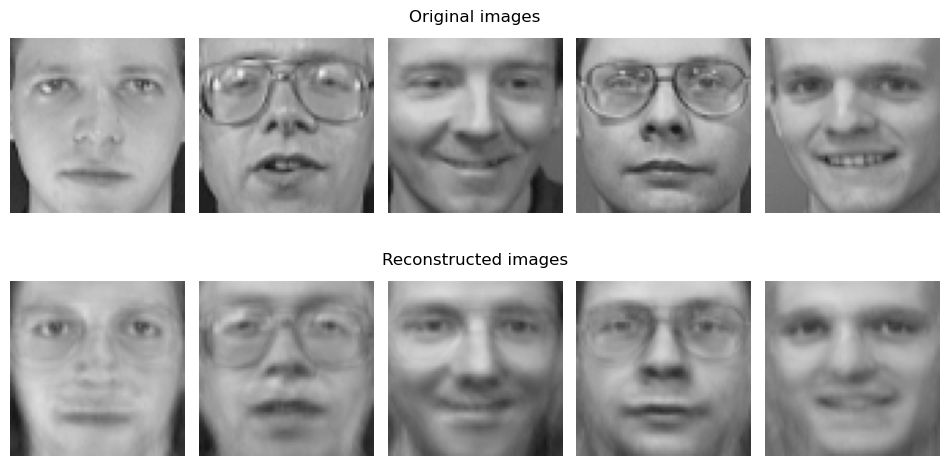

In [12]:
# Visualize the original and reconstructed images
indices = [0, 10, 20, 30, 40]

fig, axes = plt.subplots(2, len(indices), figsize=(12, 5.5))

for i, idx in enumerate(indices):
    axes[0, i].imshow(images[idx], cmap="gray", vmin=0, vmax=1)
    axes[0, i].axis("off")

    axes[1, i].imshow(reconstructed_images[idx], cmap="gray", vmin=0, vmax=1)
    axes[1, i].axis("off")

axes[0, 2].set_title("Original images", fontsize=12, pad=12)
axes[1, 2].set_title("Reconstructed images", fontsize=12, pad=12)

plt.subplots_adjust(hspace=0.35, wspace=0.08)
plt.show()

## Experimentation and Visual Analysis

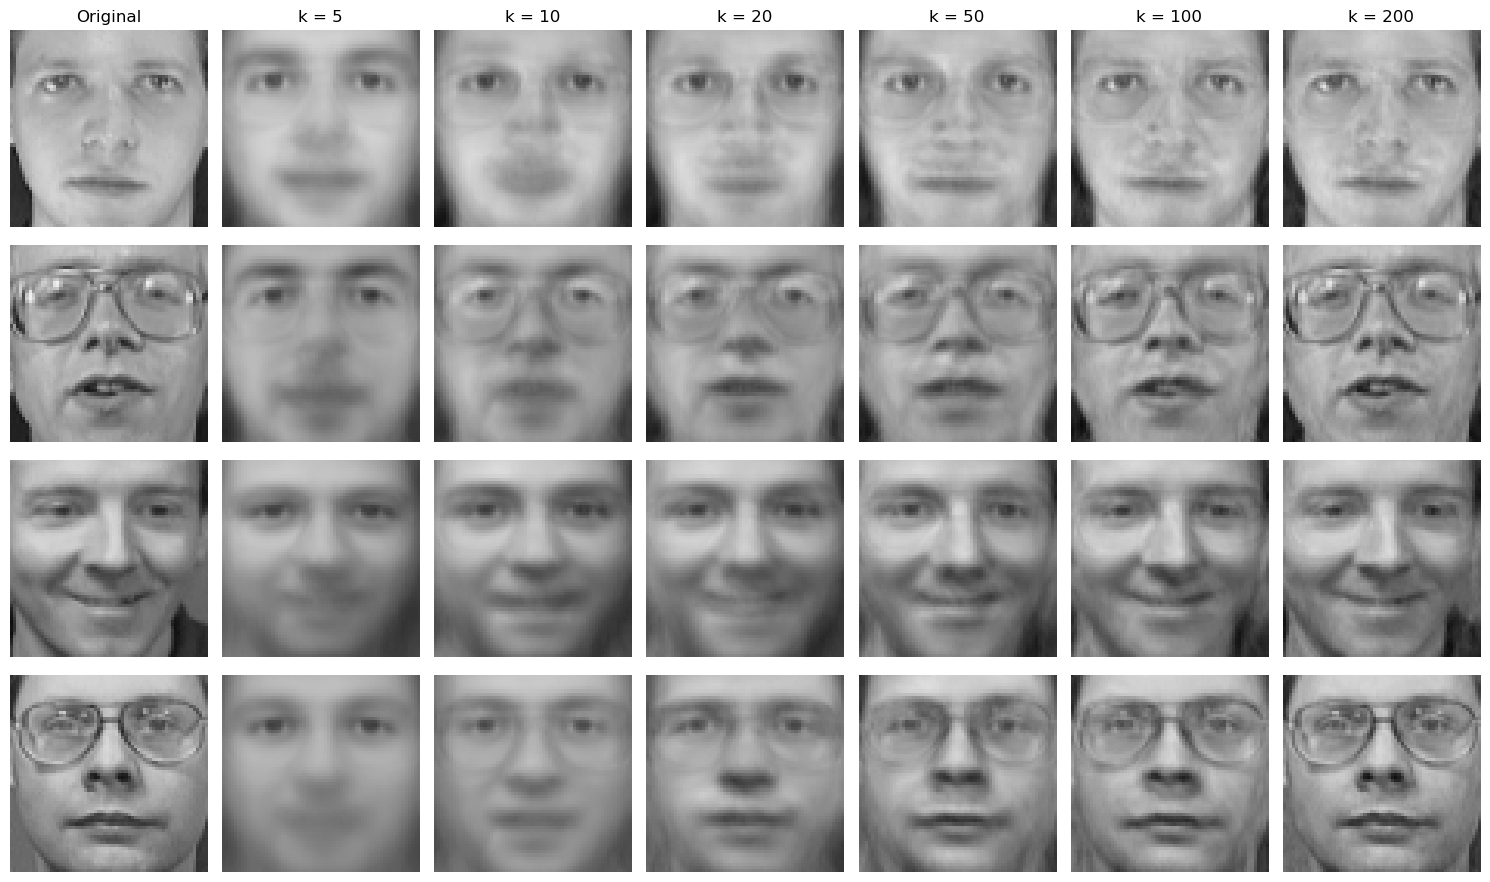

In [30]:
k_values = [5, 10, 20, 50, 100, 200]
image_indices = [0, 10, 20, 30]

fig, axes = plt.subplots(
    len(image_indices),
    len(k_values) + 1,
    figsize=(15, 9)
)

for row, image_index in enumerate(image_indices):

    # Show the original image
    axes[row, 0].imshow(
        images[image_index],
        cmap="gray",
        vmin=0,
        vmax=1
    )
    axes[row, 0].axis("off")

    # Reconstruct the image for each value of k
    for col, k in enumerate(k_values):
        components = eigenvectors[:, :k]

        # Project onto the selected principal components
        X_projected_k = X_centered @ components

        # Reconstruct the images in the original pixel space
        X_reconstructed_k = (
            X_projected_k @ components.T + mean_image
        )

        reconstructed_image = (
            X_reconstructed_k[image_index].reshape(64, 64)
        )

        axes[row, col + 1].imshow(
            reconstructed_image,
            cmap="gray",
            vmin=0,
            vmax=1
        )
        axes[row, col + 1].axis("off")

# Add column titles
axes[0, 0].set_title("Original")

for col, k in enumerate(k_values):
    axes[0, col + 1].set_title(f"k = {k}")

# Add labels for each person
for row, image_index in enumerate(image_indices):
    axes[row, 0].set_ylabel(
        f"Person {targets[image_index]}",
        fontsize=11
    )

plt.tight_layout()
plt.show()

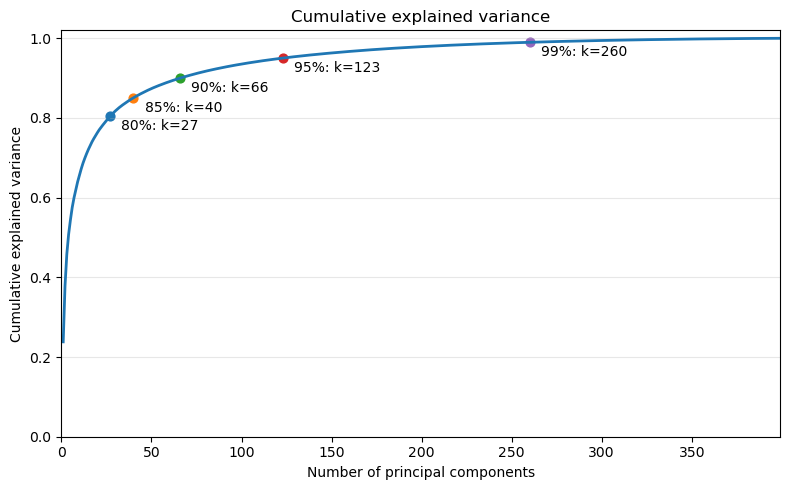

In [32]:
# Plot cumulative explained variance for the meaningful PCA components
plt.figure(figsize=(8, 5))

x = np.arange(1, 400)
y = cumulative_variance[:399]

plt.plot(x, y, linewidth=2)

# Variance levels used to evaluate suitable values of k
thresholds = [0.80, 0.85, 0.90, 0.95, 0.99]

for threshold in thresholds:
    # Find the smallest k that reaches the given variance level
    k = np.argmax(cumulative_variance >= threshold) + 1
    
    # Mark the corresponding point on the curve
    plt.scatter(k, cumulative_variance[k - 1], s=40)

    # Add the variance level and k value to the plot
    plt.annotate(
        f"{threshold * 100:.0f}%: k={k}",
        xy=(k, cumulative_variance[k - 1]),
        xytext=(8, -10),
        textcoords="offset points"
    )

plt.xlabel("Number of principal components")
plt.ylabel("Cumulative explained variance")
plt.title("Cumulative explained variance")

plt.xlim(0, 399)
plt.ylim(0, 1.02)
plt.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

## Error Analysis

In [31]:
k_values = [5, 10, 20, 50, 66, 100, 123, 200, 300, 399]

mse_values = []

for k in k_values:
    # Select the first k principal components
    components = eigenvectors[:, :k]

    # Project the images
    X_projected_k = X_centered @ components

    # Reconstruct the images
    X_reconstructed_k = (
        X_projected_k @ components.T + mean_image
    )

    # Calculate MSE across all images and pixels
    mse = np.mean((X - X_reconstructed_k) ** 2)
    mse_values.append(mse)

    print(f"k = {k:3d}: MSE = {mse:.6f}")

k =   5: MSE = 0.008789
k =  10: MSE = 0.006622
k =  20: MSE = 0.004559
k =  50: MSE = 0.002431
k =  66: MSE = 0.001922
k = 100: MSE = 0.001246
k = 123: MSE = 0.000956
k = 200: MSE = 0.000404
k = 300: MSE = 0.000106
k = 399: MSE = 0.000000


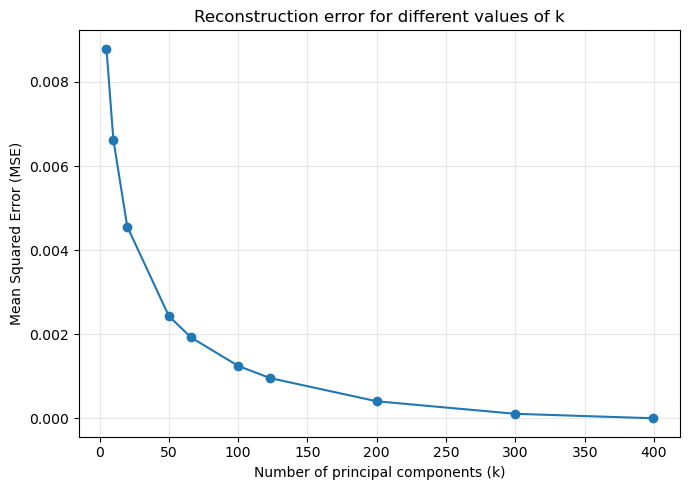

In [33]:
# Plot reconstruction error for different values of k
plt.figure(figsize=(7, 5))

plt.plot(k_values, mse_values, marker="o")

plt.xlabel("Number of principal components (k)")
plt.ylabel("Mean Squared Error (MSE)")
plt.title("Reconstruction error for different values of k")

plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()